# AgentSHAP — Runnable Notebook

This notebook shows how to use AgentSHAP to explain which tools an AI agent
relied on to answer a given prompt. It uses real tools from the API-Bank benchmark.

**Required files (in `token_shap/`):**
- `__init__.py` (simplified)
- `base.py`
- `agent_shap.py`
- `tools.py`

**Required packages:**
```
pip install openai numpy pandas matplotlib scikit-learn tqdm sentence-transformers
```

## 1. Setup

In [1]:
import sys
import os
from pathlib import Path

def find_repo_root(start_path: Path) -> Path:
    for candidate in [start_path] + list(start_path.parents):
        if (candidate / "token_shap").exists():
            return candidate
    return start_path

def load_simple_env(env_path: Path) -> None:
    if not env_path.exists():
        print(f"No .env found at {env_path}; using existing environment variables.")
        return
    for raw_line in env_path.read_text(encoding="utf-8").splitlines():
        line = raw_line.strip()
        if not line or line.startswith("#") or "=" not in line:
            continue
        key, value = line.split("=", 1)
        key = key.strip()
        value = value.strip().strip("\"'")
        os.environ.setdefault(key, value)

# Add the repo root to path so we can import token_shap
repo_root = find_repo_root(Path().resolve())
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

# Auto-load experiments/.env for notebook runs
load_simple_env(repo_root / "experiments" / ".env")

from token_shap import AgentSHAP, create_function_tool
from token_shap.base import OllamaModel, OpenAIModel, HuggingFaceEmbeddings, TfidfTextVectorizer

print("Imports OK")

c:\Users\2kaus\Documents\Codes\AgentSHAP\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Imports OK


In [2]:
MODEL_PROVIDER = os.environ.get("MODEL_PROVIDER", "ollama").lower()

OLLAMA_MODEL_NAME = os.environ.get("OLLAMA_MODEL_NAME", "qwen2.5:7b-instruct")
OLLAMA_API_URL = os.environ.get("OLLAMA_API_URL", "http://localhost:11434")

OPENAI_COMPAT_API_KEY = os.environ.get("OPENAI_COMPAT_API_KEY", os.environ.get("GEMINI_API_KEY", ""))
OPENAI_COMPAT_MODEL_NAME = os.environ.get("OPENAI_COMPAT_MODEL_NAME", os.environ.get("GEMINI_MODEL_NAME", "gemini-2.5-flash"))
OPENAI_COMPAT_BASE_URL = os.environ.get("OPENAI_COMPAT_BASE_URL", os.environ.get("GEMINI_BASE_URL", "https://generativelanguage.googleapis.com/v1beta/openai/"))

if MODEL_PROVIDER != "ollama" and not OPENAI_COMPAT_API_KEY:
    raise ValueError("Set OPENAI_COMPAT_API_KEY (or GEMINI_API_KEY) when MODEL_PROVIDER is not 'ollama'.")

print(f"Provider config loaded: {MODEL_PROVIDER}")

Provider config loaded: ollama


## 2. Define Tools

We create three simple tools that simulate real APIs:
- **Calculator** — evaluate arithmetic expressions
- **QueryStock** — look up a stock price
- **Wiki** — search Wikipedia

In [3]:
# --- Calculator ---
def calculator_fn(args):
    expression = args.get('expression', '0')
    allowed = set('0123456789+-*/.() ')
    if not all(c in allowed for c in expression):
        return 'Error: Invalid expression'
    try:
        return str(eval(expression))
    except Exception as e:
        return f'Error: {e}'

calculator_tool = create_function_tool(
    name='Calculator',
    description='Evaluate arithmetic expressions. Use this for any math calculation.',
    parameters={
        'type': 'object',
        'properties': {
            'expression': {
                'type': 'string',
                'description': 'A math expression to evaluate, e.g. "(5+6)*3"'
            }
        },
        'required': ['expression']
    },
    executor=calculator_fn
)

# --- Stock Query ---
STOCK_DB = {
    'AAPL':  {'2024-01-15': 185.92, '2024-01-16': 183.63},
    'GOOGL': {'2024-01-15': 141.80, '2024-01-16': 140.23},
    'MSFT':  {'2024-01-15': 388.47, '2024-01-16': 390.11},
    'TSLA':  {'2024-01-15': 218.89, '2024-01-16': 212.19},
    'SQ':    {'2022-03-14': 92.34,  '2022-03-15': 89.12},
}

def query_stock_fn(args):
    symbol = args.get('symbol', '').upper()
    date   = args.get('date', '')
    if symbol in STOCK_DB:
        prices = STOCK_DB[symbol]
        if date in prices:
            return f'{symbol} on {date}: ${prices[date]}'
        # Return the most recent price if no date match
        latest_date = sorted(prices.keys())[-1]
        return f'{symbol} (latest, {latest_date}): ${prices[latest_date]}'
    return f'No data found for symbol {symbol}'

stock_tool = create_function_tool(
    name='QueryStock',
    description='Look up the stock price for a given ticker symbol and optional date.',
    parameters={
        'type': 'object',
        'properties': {
            'symbol': {
                'type': 'string',
                'description': 'Stock ticker symbol, e.g. "AAPL" or "TSLA"'
            },
            'date': {
                'type': 'string',
                'description': 'Date in YYYY-MM-DD format (optional)'
            }
        },
        'required': ['symbol']
    },
    executor=query_stock_fn
)

# --- Wikipedia Search ---
WIKI_DB = {
    'python':           'Python is a high-level, general-purpose programming language known for its readability.',
    'artificial intelligence': 'Artificial intelligence (AI) is the simulation of human intelligence in machines.',
    'machine learning': 'Machine learning is a subset of AI that enables systems to learn from data.',
    'newton':           'Isaac Newton was an English mathematician and physicist, famous for the laws of motion.',
    'einstein':         'Albert Einstein developed the theory of relativity and won the Nobel Prize in Physics in 1921.',
}

def wiki_fn(args):
    query = args.get('query', '').lower()
    for key, value in WIKI_DB.items():
        if key in query or query in key:
            return value
    return f'No Wikipedia article found for "{query}"'

wiki_tool = create_function_tool(
    name='Wiki',
    description='Search Wikipedia for factual information about a topic.',
    parameters={
        'type': 'object',
        'properties': {
            'query': {
                'type': 'string',
                'description': 'The topic to search for on Wikipedia'
            }
        },
        'required': ['query']
    },
    executor=wiki_fn
)

tools = [calculator_tool, stock_tool, wiki_tool]
print(f'Tools defined: {[t.name for t in tools]}')

Tools defined: ['Calculator', 'QueryStock', 'Wiki']


## 3. Initialise the Model and Vectorizer

By default this notebook uses Ollama (`MODEL_PROVIDER=ollama`) with
`qwen2.5:7b-instruct` for the agent and local HuggingFace embeddings for
response similarity. You can switch to an OpenAI-compatible cloud provider
by setting `MODEL_PROVIDER` and the `OPENAI_COMPAT_*` environment variables.

If you want an even lighter option, swap the vectorizer for
`TfidfTextVectorizer()` (fully local, less semantic than embeddings).

In [4]:
if MODEL_PROVIDER == "ollama":
    model = OllamaModel(
        model_name=OLLAMA_MODEL_NAME,
        api_url=OLLAMA_API_URL,
    )
else:
    model = OpenAIModel(
        model_name=OPENAI_COMPAT_MODEL_NAME,
        api_key=OPENAI_COMPAT_API_KEY,
        base_url=OPENAI_COMPAT_BASE_URL,
    )

# Option A: Local HuggingFace embeddings (free, semantic similarity)
vectorizer = HuggingFaceEmbeddings(model_name='sentence-transformers/all-MiniLM-L6-v2')

# Option B: TF-IDF (free, offline, slightly less accurate)
# vectorizer = TfidfTextVectorizer()

print(f"Model and vectorizer ready. Provider={MODEL_PROVIDER}")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 4882.17it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model and vectorizer ready. Provider=ollama


## 4. Run AgentSHAP — Single Prompt

We analyse a single prompt and print the Shapley values for each tool.

In [5]:
agent_shap = AgentSHAP(
    model=model,
    tools=tools,
    vectorizer=vectorizer,
    max_iterations=3,
    debug=True          # Set to True to see detailed logs
)

# prompt = 'What is the stock price of SQ on March 14th, 2022?'

# results_df, shapley_values = agent_shap.analyze(
#     prompt=prompt,
#     sampling_ratio=0.5   # 0.0 = essential combinations only; 1.0 = exhaustive
# )

# print('\nShapley Values:')
# for tool, value in sorted(shapley_values.items(), key=lambda x: x[1], reverse=True):
#     print(f'  {tool:<15} {value:.4f}')

## 5. Visualise Results

In [ ]:
# # Text-based importance ranking
# agent_shap.print_tool_ranking()


TOOL IMPORTANCE RANKING (AgentSHAP)
1. QueryStock #################### 0.7938
2. Wiki       #####............... 0.2062
3. Calculator .................... 0.0000


In [7]:
import matplotlib.pyplot as plt

# # Bar chart
# fig = agent_shap.plot_tool_importance(title=f'Tool Importance — "{prompt}"')
# plt.show()

In [ ]:
# # Coloured text (red = high importance, blue = low importance)
# print('Coloured tool ranking:')
# agent_shap.print_colored_tools()

Coloured tool ranking:
QueryStock  Wiki  Calculator  


In [ ]:
# # Inspect the full results DataFrame
# print('Combination results:')
# results_df[['tools_available', 'similarity']].sort_values('similarity', ascending=False)

Combination results:


,tools_available,similarity
0,QueryStock+Wiki,1.000000
2,Calculator+QueryStock,1.000000
4,QueryStock,1.000000
3,Calculator,0.658379
1,Calculator+Wiki,0.598486


## 6. Compare Tool Importance Across Multiple Prompts

This shows how the same agent assigns different importance to tools
depending on what the user is asking.


Prompt 1/3: Can you calculate (5+6)*3 for me?...

Analyzing 3 tools:
  - Calculator
  - QueryStock
  - Wiki

1. Getting baseline response (all tools)...
Tool usage for baseline: {'Calculator': 1}
Baseline response: The result of the expression (5+6)*3 is 33....

2. Testing tool combinations...
Number of tools: 3
Number of essential combinations (each missing one tool): 3
Additional combinations to sample: 2
Total combinations to process: 5


Testing tool combinations:   0%|          | 0/5 [00:00<?, ?it/s]


Combination 1: ['QueryStock', 'Wiki']


Testing tool combinations:  20%|██        | 1/5 [00:39<02:36, 39.25s/it]

Tool usage for QueryStock+Wiki_idx2,3: {}

Combination 2: ['Calculator', 'Wiki']


...

Testing tool combinations:  80%|████████  | 4/5 [03:26<00:48, 48.23s/it]

Tool usage for QueryStock_idx2: {}

Combination 5: ['Wiki']


Testing tool combinations: 100%|██████████| 5/5 [04:10<00:00, 50.15s/it]

Tool usage for Wiki_idx3: {'Wiki': 1}

3. Calculating similarities...

4. Computing Shapley values...



 Analysis complete!


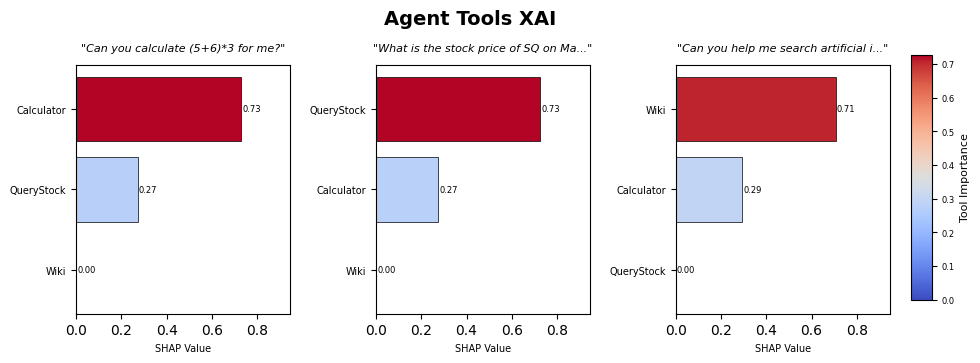

In [11]:
prompts = [
    'Can you calculate (5+6)*3 for me?',                          # Should highlight Calculator
    'What is the stock price of SQ on March 14th, 2022?',        # Should highlight QueryStock
    'Can you help me search artificial intelligence on Wikipedia?', # Should highlight Wiki
]

fig, all_shap_values = agent_shap.compare_prompts(
    prompts=prompts,
    sampling_ratio=0.5
)

In [12]:
plt.show()

## 7. Tool Usage Summary

After running `compare_prompts`, `agent_shap` stores the results from the
**last prompt** analysed. We can inspect the tool usage for that prompt.

In [17]:
summary = agent_shap.get_tool_usage_summary()
print(f'Tool usage summary for last prompt ("{prompts[-1]}"):')
print(summary.to_string(index=False))

Tool usage summary for last prompt ("Can you help me search artificial intelligence on Wikipedia?"):
 tool_name  total_calls  baseline_calls  shap_value
      Wiki            4               1    0.705911
Calculator            0               0    0.294089
QueryStock            0               0    0.000000


## 8. Detailed Results

You can access the full internal state after any `analyze()` call.

In [14]:
details = agent_shap.get_detailed_results()

print('Prompt:', details['prompt'])
print()
print('Baseline response (all tools available):')
print(details['baseline_response'])
print()
print('Baseline tool usage:', details['baseline_tool_usage'])
print()
print('Shapley values:', details['shapley_values'])

Prompt: Can you help me search artificial intelligence on Wikipedia?

Baseline response (all tools available):
Here's a brief overview from Wikipedia: Artificial intelligence (AI) is the simulation of human intelligence in machines. If you need more detailed information or specific sections, let me know!

Baseline tool usage: {'Wiki': 1}

Shapley values: {'Calculator': np.float32(0.2940892), 'QueryStock': np.float32(0.0), 'Wiki': np.float32(0.7059108)}


## 9. Quick Reference

| Parameter | What it does |
|---|---|
| `sampling_ratio=0.0` | Only essential combinations (fast, less accurate) |
| `sampling_ratio=0.5` | Half of all possible combinations (balanced) |
| `sampling_ratio=1.0` | Exhaustive — all 2^n combinations (slow, most accurate) |
| `max_combinations=N` | Hard cap on total combinations regardless of ratio |
| `max_iterations=3` | Max tool-calling rounds per combination |
| `debug=True` | Print verbose logs during analysis |